<a href="https://colab.research.google.com/github/luisaorcales113-design/luisaaliana/blob/main/Week_3__Pandas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<img align="center" src="https://cs5.pikabu.ru/post_img/2014/09/21/1/1411252786_329748226.jpg" width="300">




## Week 3: Working with Tables (Exploratory Data Analysis. EDA)

In this seminar, we will discuss working with tables, visualization, and music (perhaps bad music).




In [1]:
'/content/youtube_data_short.csv'

'/content/youtube_data_short.csv'

In [2]:
import numpy as np         # library for matrices and mathematics
import pandas as pd        # library for working with tables
from scipy import stats    # module for working with statistics

# libraries for visualization
import matplotlib.pyplot as plt
import seaborn as sns

# set parameters for the plots we create, such as size
plt.rcParams['figure.figsize'] = (10, 5)

Data is conveniently represented in the form of tables. Typically, the rows of such tables contain observations, and the columns contain variables.

<img src="https://raw.githubusercontent.com/MidiukinM/Python/main/images/table.png" width="400">

We will not stop repeating that everything in _python_ is an object. For such tables, there is also a specific type of object - `DataFrame` from the pandas package.

A `DataFrame` contains several other objects: `Index` and `Series` objects:
* `Index` - this is how your rows are numbered. Usually, the index is a range of numbers from 0 to the number of rows, but it can also be something else, for example, in the image above, the index consists of car models.
* `Series` - this is an object for a single column of a DataFrame.




In [3]:
# Choosing a name for the child
dct = {
    'name': ['Ragneda', 'Zasipotor', 'January', 'Celomudr', 'Patonius', 'Raboletina', 'Svobodolyubava', 'Karpecia'],
    'score': [6, 2, 1, 4, 6, 0, 8, 5]
}

df = pd.DataFrame(dct)
df.head()

,name,score
0,Ragneda,6
1,Zasipotor,2
2,January,1
3,Celomudr,4
4,Patonius,6


In [4]:
type(df)

pandas.core.frame.DataFrame

You can unpack a table into its components:

- Column names
- Row indices
- Data matrix

In [5]:
df.columns

Index(['name', 'score'], dtype='object')

In [6]:
df.columns.values

array(['name', 'score'], dtype=object)

In [7]:
df.index

RangeIndex(start=0, stop=8, step=1)

In [8]:
df.index.values

array([0, 1, 2, 3, 4, 5, 6, 7])

In [9]:
df.values

array([['Ragneda', 6],
       ['Zasipotor', 2],
       ['January', 1],
       ['Celomudr', 4],
       ['Patonius', 6],
       ['Raboletina', 0],
       ['Svobodolyubava', 8],
       ['Karpecia', 5]], dtype=object)

All three objects are vectors and matrices from `numpy`.

## 1. Inspecting the Data

Let's analyze data related to music. We'll load the data and see what's inside our table. We will do this using the [pd.read_csv()](http://pandas.pydata.org/pandas-docs/stable/generated/pandas.read_csv.html#pandas.read_csv) command.

This function has many arguments, with the most critical ones being:

- **filepath_or_buffer** — a string containing the file name (or address)
- **sep** — the delimiter between data entries
- **header** — the row number in the file that contains the column names, or None if there isn't one
- **names** — a list of column names
- **index_col** — either the column number, a list of columns, or nothing (to use the row names)

In [10]:
# Load data
df = pd.read_csv("youtube_data_short.csv", sep = "\t")

# first 5 rows
df.head()

,title,commentCount,dislikeCount,likeCount,music_style,performer,viewCount,commentators_uniq,comments_obscene_cnt,video_age
0,"""#2Маши ""Свободные линии""",34.0,43.0,1402.0,popsa,2маши,214301.0,24.0,0.0,1141
1,"""ALARM"" СЕРГЕЙ ЛАЗАРЕВ ( SERGEY LAZAREV )",NaN,690.0,10532.0,popsa,лазарев,2221419.0,NaN,NaN,3217
2,"""EARTH SONG"" SERGEY LAZAREV. DEDICATED TO MIC...",26.0,10.0,269.0,popsa,лазарев,40327.0,23.0,0.0,3546
3,"""Earth song"" премия МУЗ-тВ 2010 (LIVE)",12.0,7.0,163.0,popsa,лазарев,11907.0,11.0,0.0,3189
4,"""FAKE"" СЕРГЕЙ ЛАЗАРЕВ (SERGEY)",46.0,19.0,597.0,popsa,лазарев,91483.0,33.0,1.0,3361


In [11]:
# last 5 rows
df.tail()

,title,commentCount,dislikeCount,likeCount,music_style,performer,viewCount,commentators_uniq,comments_obscene_cnt,video_age
19119,♫♪Мы расстаемся ♫♪ Бутырка new2019,2.0,0.0,11.0,shanson,бутырка,1107.0,NaN,NaN,44
19120,❤ 2 ЧАСА ❤ МОЦАРТ Для Младенцев - Колыбельная ...,94.0,431.0,1837.0,classic,classical_channel,391836.0,37.0,1.0,239
19121,モスクワライブショー ' 17,4872.0,15494.0,30603.0,rap,элджей,1187340.0,1788.0,352.0,339
19122,舞梅鬼 - 新年好宝贝 / Mumiy Troll - Happy New Year ...,59.0,10.0,260.0,rock,мумий_тролль,10147.0,19.0,0.0,997
19123,🎄#премьера песни!!! 2019г(вы не спешите говори...,1.0,0.0,22.0,shanson,бутырка,1566.0,NaN,NaN,65


In [12]:
df.shape

(19124, 10)

In [13]:
df[105:112]

,title,commentCount,dislikeCount,likeCount,music_style,performer,viewCount,commentators_uniq,comments_obscene_cnt,video_age
105,"""Первая четверть"" Юбилейный концерт в Олимпийс...",11.0,0.0,125.0,rock,арбенина,2225.0,NaN,NaN,8
106,"""Первая четверть"" юбилейный концерт Дианы Арбе...",43.0,3.0,399.0,rock,арбенина,3177.0,NaN,NaN,0
107,"""Перелётная птица"" [Москва, 2012г.]",2.0,3.0,56.0,shanson,ирина_круг,8325.0,2.0,0.0,1984
108,"""Пока ещё не поздно"". Михаил Круг. Жизнь и люб...",7.0,7.0,108.0,shanson,ирина_круг,29928.0,5.0,0.0,2148
109,"""Пока ещё не поздно"". Михаил Круг. Любовь и см...",15.0,11.0,158.0,shanson,ирина_круг,27185.0,9.0,0.0,2148
110,"""Последний герой"" с Дианой Арбениной - пре...",1.0,1.0,31.0,rock,арбенина,1953.0,1.0,0.0,892
111,"""Последний герой: Павел Кашин (тизер программы...",0.0,1.0,9.0,rock,арбенина,954.0,NaN,NaN,757


__Column Descriptions:__

- `title` — video title
- `commentCount` — number of comments
- `dislikeCount` — number of dislikes
- `likeCount`  — number of likes
- `music_style` — music genre
- `performer` — performer
- `viewCount` — number of views
- `commentators_uniq` — number of unique commentators
- `comments_obscene_cnt` — number of comments with obscene language
- `video_age` — video age in days

The video age is calculated in days relative to `2019-03-15`. You can view the main information about the columns using the `.info()` method. Next to each column name, you can see how many cells are filled in that column. For example, for $18,850$ videos out of $19,124$ (total number of rows), there is information about the number of likes, `likeCount`. This means there are $274$ rows with missing values, `NaN`.


In [14]:
# Information about our table
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19124 entries, 0 to 19123
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   title                 19124 non-null  object 
 1   commentCount          18914 non-null  float64
 2   dislikeCount          18850 non-null  float64
 3   likeCount             18850 non-null  float64
 4   music_style           19124 non-null  object 
 5   performer             19124 non-null  object 
 6   viewCount             19123 non-null  float64
 7   commentators_uniq     12314 non-null  float64
 8   comments_obscene_cnt  12314 non-null  float64
 9   video_age             19124 non-null  int64  
dtypes: float64(6), int64(1), object(3)
memory usage: 1.5+ MB


In [15]:
# Only the data types of the variables
df.dtypes


,0
title,object
commentCount,float64
dislikeCount,float64
likeCount,float64
music_style,object
performer,object
viewCount,float64
commentators_uniq,float64
comments_obscene_cnt,float64
video_age,int64



__Classification of Variables by Data Type:__  

* `int` — numerical, integer values (1000, 0, -1)
* `float` — numerical, floating-point numbers (1.0, 2.564523)
* `object` — string values (butyrka, rock, f12aaz//)
* `bool` — boolean values (True, False)
* `datetime` — date values (2020-01-12, 23.Jan.20)

__Classification of Variables by Meaning:__  

* `Continuous` — contains a continuous range of values over an interval (salary, human height, bread loaf weight, etc.)
* `Categorical` — contains a finite small set of values (children's age, store type)
* `Binary` — a subtype of categorical variable with only 2 categories (gender, capitals of two countries)


## 2. Base skills for working with tables

Get columns. The result - an object of class Series.

In [16]:
df['likeCount']

,likeCount
0,1402.0
1,10532.0
2,269.0
3,163.0
4,597.0
...,...
19119,11.0
19120,1837.0
19121,30603.0
19122,260.0


In [17]:
df.likeCount # second way

,likeCount
0,1402.0
1,10532.0
2,269.0
3,163.0
4,597.0
...,...
19119,11.0
19120,1837.0
19121,30603.0
19122,260.0


In [18]:
type(df['likeCount'])

pandas.core.series.Series

Extract values from the column. The result is a numpy array.

In [19]:
df.likeCount.values

array([1.4020e+03, 1.0532e+04, 2.6900e+02, ..., 3.0603e+04, 2.6000e+02,
       2.2000e+01])

In [20]:
type(df.likeCount.values)

numpy.ndarray

In [21]:
# loc - using names of a row and a column
df.loc[[45, 50], ['title', 'likeCount']]

,title,likeCount
45,"""Глаза - убийцы"". Первые впечатления",23.0
50,"""ДОстояние РЕспублики"" - Игорь Николаев (1)",80.0


Conditional slices

In [22]:
# Extract several columns
df[['title', 'performer']].head()

,title,performer
0,"""#2Маши ""Свободные линии""",2маши
1,"""ALARM"" СЕРГЕЙ ЛАЗАРЕВ ( SERGEY LAZAREV )",лазарев
2,"""EARTH SONG"" SERGEY LAZAREV. DEDICATED TO MIC...",лазарев
3,"""Earth song"" премия МУЗ-тВ 2010 (LIVE)",лазарев
4,"""FAKE"" СЕРГЕЙ ЛАЗАРЕВ (SERGEY)",лазарев


In [23]:
# columns can be saved as a separate array
useful_cols = ['title', 'performer']
df[useful_cols].head()

,title,performer
0,"""#2Маши ""Свободные линии""",2маши
1,"""ALARM"" СЕРГЕЙ ЛАЗАРЕВ ( SERGEY LAZAREV )",лазарев
2,"""EARTH SONG"" SERGEY LAZAREV. DEDICATED TO MIC...",лазарев
3,"""Earth song"" премия МУЗ-тВ 2010 (LIVE)",лазарев
4,"""FAKE"" СЕРГЕЙ ЛАЗАРЕВ (SERGEY)",лазарев


In [24]:
# clips with 0 likes
df.loc[df.likeCount == 0].head()

,title,commentCount,dislikeCount,likeCount,music_style,performer,viewCount,commentators_uniq,comments_obscene_cnt,video_age
429,1. конф.,0.0,0.0,0.0,rock,несчастный_случай,17.0,NaN,NaN,293
464,16:45 (без четверти пять),0.0,0.0,0.0,rock,несчастный_случай,91.0,NaN,NaN,293
481,2. конф.,0.0,0.0,0.0,rock,несчастный_случай,11.0,NaN,NaN,293
519,3. конф.,0.0,0.0,0.0,rock,несчастный_случай,9.0,NaN,NaN,293
558,4. конф.,0.0,0.0,0.0,rock,несчастный_случай,9.0,NaN,NaN,293


In [25]:
# same but select several columns
df.loc[df.likeCount == 0, ['title', 'performer']].head()

,title,performer
429,1. конф.,несчастный_случай
464,16:45 (без четверти пять),несчастный_случай
481,2. конф.,несчастный_случай
519,3. конф.,несчастный_случай
558,4. конф.,несчастный_случай


In [26]:
# several conditions
df.loc[(df.likeCount > 0) & (df.dislikeCount == 0)].head()

,title,commentCount,dislikeCount,likeCount,music_style,performer,viewCount,commentators_uniq,comments_obscene_cnt,video_age
36,"""ВОИН ДУМА""",4.0,0.0,49.0,rock,король_и_шут,1950.0,NaN,NaN,3819
70,"""КРАЯ РОДНЫЕ"" гр. ""Воровайки"", слова Виктории ...",0.0,0.0,1.0,shanson,воровайки,418.0,NaN,NaN,479
74,"""Король и Шут"" - 15 лет",5.0,0.0,62.0,rock,король_и_шут,6547.0,5.0,0.0,3817
87,"""Мумий Тролль"" уходит в море. Отход ""Седова"".",3.0,0.0,70.0,rock,мумий_тролль,6327.0,3.0,0.0,2482
93,"""НЕ УБЕРЕГЛА ЛЮБОВЬ"" (Audio) гр. ""Воровайки"", ...",0.0,0.0,2.0,shanson,воровайки,985.0,NaN,NaN,499


In [27]:
# Conditions might be saved to variables
first_cond = df.likeCount > 0
second_cond = df.dislikeCount == 0

df.loc[first_cond & second_cond].head()

,title,commentCount,dislikeCount,likeCount,music_style,performer,viewCount,commentators_uniq,comments_obscene_cnt,video_age
36,"""ВОИН ДУМА""",4.0,0.0,49.0,rock,король_и_шут,1950.0,NaN,NaN,3819
70,"""КРАЯ РОДНЫЕ"" гр. ""Воровайки"", слова Виктории ...",0.0,0.0,1.0,shanson,воровайки,418.0,NaN,NaN,479
74,"""Король и Шут"" - 15 лет",5.0,0.0,62.0,rock,король_и_шут,6547.0,5.0,0.0,3817
87,"""Мумий Тролль"" уходит в море. Отход ""Седова"".",3.0,0.0,70.0,rock,мумий_тролль,6327.0,3.0,0.0,2482
93,"""НЕ УБЕРЕГЛА ЛЮБОВЬ"" (Audio) гр. ""Воровайки"", ...",0.0,0.0,2.0,shanson,воровайки,985.0,NaN,NaN,499


Create a new variable. Ration of number of likes by the number of views.

In [28]:
df["likePerShow"]= df['likeCount']/df['viewCount']
df.head(2)

,title,commentCount,dislikeCount,likeCount,music_style,performer,viewCount,commentators_uniq,comments_obscene_cnt,video_age,likePerShow
0,"""#2Маши ""Свободные линии""",34.0,43.0,1402.0,popsa,2маши,214301.0,24.0,0.0,1141,0.006542
1,"""ALARM"" СЕРГЕЙ ЛАЗАРЕВ ( SERGEY LAZAREV )",NaN,690.0,10532.0,popsa,лазарев,2221419.0,NaN,NaN,3217,0.004741


In [29]:
df.likePerShow.max() # WHAT ???

np.float64(inf)

In [30]:
df['viewCount'].min() # We've divided by zero!

0.0

In [31]:
df["likePerShow"]= df['likeCount']/(df['viewCount'] + 1e-8)
df.likePerShow.max() # better :)

191000000000.0

Let's divide a column with unique commentators.

In [32]:
df.drop('commentators_uniq', axis=1).head(2)

,title,commentCount,dislikeCount,likeCount,music_style,performer,viewCount,comments_obscene_cnt,video_age,likePerShow
0,"""#2Маши ""Свободные линии""",34.0,43.0,1402.0,popsa,2маши,214301.0,0.0,1141,0.006542
1,"""ALARM"" СЕРГЕЙ ЛАЗАРЕВ ( SERGEY LAZAREV )",NaN,690.0,10532.0,popsa,лазарев,2221419.0,NaN,3217,0.004741


This transformation is not `inplace`. This means that it only occurred in the cell above. If we call the table again, the removed column will still be there.




In [33]:
df.head(2)

,title,commentCount,dislikeCount,likeCount,music_style,performer,viewCount,commentators_uniq,comments_obscene_cnt,video_age,likePerShow
0,"""#2Маши ""Свободные линии""",34.0,43.0,1402.0,popsa,2маши,214301.0,24.0,0.0,1141,0.006542
1,"""ALARM"" СЕРГЕЙ ЛАЗАРЕВ ( SERGEY LAZAREV )",NaN,690.0,10532.0,popsa,лазарев,2221419.0,NaN,NaN,3217,0.004741


If we want to drop a column, we need to overwrite the table. Alternatively, we can specify that the transformation should be `inplace` in the arguments.



In [34]:
df.drop('commentators_uniq', axis=1, inplace=True)
df.head(2)

,title,commentCount,dislikeCount,likeCount,music_style,performer,viewCount,comments_obscene_cnt,video_age,likePerShow
0,"""#2Маши ""Свободные линии""",34.0,43.0,1402.0,popsa,2маши,214301.0,0.0,1141,0.006542
1,"""ALARM"" СЕРГЕЙ ЛАЗАРЕВ ( SERGEY LAZAREV )",NaN,690.0,10532.0,popsa,лазарев,2221419.0,NaN,3217,0.004741


We can also rename columns.



In [35]:
df.rename(columns={'video_age': 'videoAge'}, inplace=True)

We can apply the same function to each cell in a column using the `apply` method. Let's count the number of letters in the title of each video in the table:

In [36]:
df.title.apply(len)[:10]

,title
0,25
1,41
2,75
3,38
4,30
5,48
6,36
7,43
8,29
9,56


In [37]:
df.title.apply(len).mean() # mean len of Title

np.float64(35.293871574984315)

You can write your own function and apply it to a column. For example, here's how you can extract the first letter of each name:


In [38]:
def my_function(name):
    return name[0]

example = "Nastya"

my_function(example)

'N'

In [39]:
df.title.apply(my_function)[-10:]


,title
19114,♫
19115,♫
19116,♫
19117,♫
19118,♫
19119,♫
19120,❤
19121,モ
19122,舞
19123,🎄


In [40]:
df.title.apply(lambda name: name[0])[-10:]

,title
19114,♫
19115,♫
19116,♫
19117,♫
19118,♫
19119,♫
19120,❤
19121,モ
19122,舞
19123,🎄


You can do exactly the same thing in one line using lambda functions. A lambda function is like a regular function, but you don't need to declare it anywhere.



In [41]:
df.title.apply(lambda name: name[0])[-10:]

,title
19114,♫
19115,♫
19116,♫
19117,♫
19118,♫
19119,♫
19120,❤
19121,モ
19122,舞
19123,🎄



Now we've reached the most important part. In `pandas`, you can search for answers to various questions. Let's get started.


### Task 1:

In the `performer` column, performers are listed. How many unique performers are there in the data? How frequently do they appear?


In [42]:
print(f"Number of unique performers: {df['performer'].nunique()}")
print("\nFrequency of each performer:")
print(df['performer'].value_counts())

Number of unique performers: 111

Frequency of each performer:
performer
николаев           566
валерия            525
михайлов           516
ваенга             503
михаил_круг        487
                  ... 
монеточка           16
пошлая_молли        14
хаски               11
деревянные киты      9
агутин               3
Name: count, Length: 111, dtype: int64


### Task 2:
How many videos in a genre different from "popsa" received more than one hundred likes?

In [43]:
non_popsa_videos = df[df['music_style'] != 'popsa']
videos_with_more_than_hundred_likes = non_popsa_videos[non_popsa_videos['likeCount'] > 100]

num_videos = videos_with_more_than_hundred_likes.shape[0]
print(f"Number of videos in a genre different from 'popsa' with more than 100 likes: {num_videos}")

Number of videos in a genre different from 'popsa' with more than 100 likes: 7172


## 3. Descriptive Statistics

In `pandas`, you can calculate all the descriptive statistics that you learned in your math stat lectures.

In [44]:
# All statistics for continuous variables
df.describe()

,commentCount,dislikeCount,likeCount,viewCount,comments_obscene_cnt,videoAge,likePerShow
count,18914.000000,18850.000000,1.885000e+04,1.912300e+04,12314.000000,19124.000000,1.884900e+04
mean,394.026065,745.344297,5.735014e+03,8.436486e+05,8.952899,1389.772642,1.240384e+07
std,4200.463284,9339.777800,3.890303e+04,6.382348e+06,37.887947,1054.261698,1.407201e+09
min,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000e+00
25%,0.000000,1.000000,1.800000e+01,1.915000e+03,0.000000,378.000000,4.508373e-03
50%,5.000000,5.000000,1.000000e+02,1.135300e+04,0.000000,1213.000000,8.773197e-03
75%,35.000000,38.000000,6.367500e+02,8.180900e+04,2.000000,2218.000000,1.578473e-02
max,303077.000000,640698.000000,1.686810e+06,2.720477e+08,693.000000,4574.000000,1.910000e+11


For each variable, we see:

- count — the number of non-missing observations
- mean — the mean value
- std — the standard deviation
- min — the minimum value
- max — the maximum value
- 50% — the median (half of the data is above this value, half is below)
- 25% — the 25% quantile (quarter of the data is below this value, 75% is above)

In [45]:
# The same, but for variables of type object
df.describe(include='object')

,title,music_style,performer
count,19124,19124,19124
unique,18029,7,111
top,Алексей Кортнев и Валдис Пельш в проекте «Две ...,rock,николаев
freq,11,5888,566


- count — the number of non-missing observations
- unique — the number of unique values (categories) that the variable can take
- top — the mode for each category
- freq — the frequency with which the mode occurs

You can also calculate specific statistics.

In [46]:
print(df.likeCount.max())
print(df.likeCount.min())

1686810.0
0.0


### Task 3:
Which video received the most likes?

In [47]:
most_liked_video = df.loc[df['likeCount'].idxmax()]
print(f"Title: {most_liked_video['title']}")
print(f"Likes: {most_liked_video['likeCount']}")

Title: Элджей & Feduk - Розовое вино
Likes: 1686810.0


**Mean, Median, and Mode**

<img src="https://raw.githubusercontent.com/MidiukinM/Python/main/images/means.jpg" width="400">

In [48]:
print(df.videoAge.mean())
print(df.videoAge.median())
print(df.videoAge.mode())

1389.7726417067558
1213.0
0    267
Name: videoAge, dtype: int64


**Variance and Standard Deviation**

In [49]:
print(df.likeCount.var())
print(df.likeCount.std())

1513445598.635849
38903.02814223912


**Quantiles and Distribution**


In [50]:
# Quantile
df.videoAge.quantile(0.99)

np.float64(3730.0)

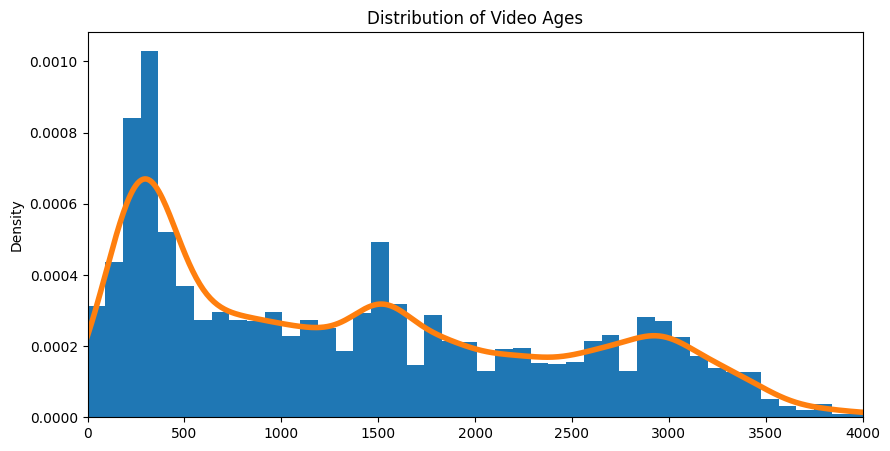

In [51]:
# You can plot histograms
plt.figure(figsize=(10,5))

df.videoAge.hist(bins=50, density=True)
df.videoAge.plot(kind='kde', linewidth=4)
plt.xlim(0, 4000)
plt.title("Distribution of Video Ages");


You can plot many histograms at once!

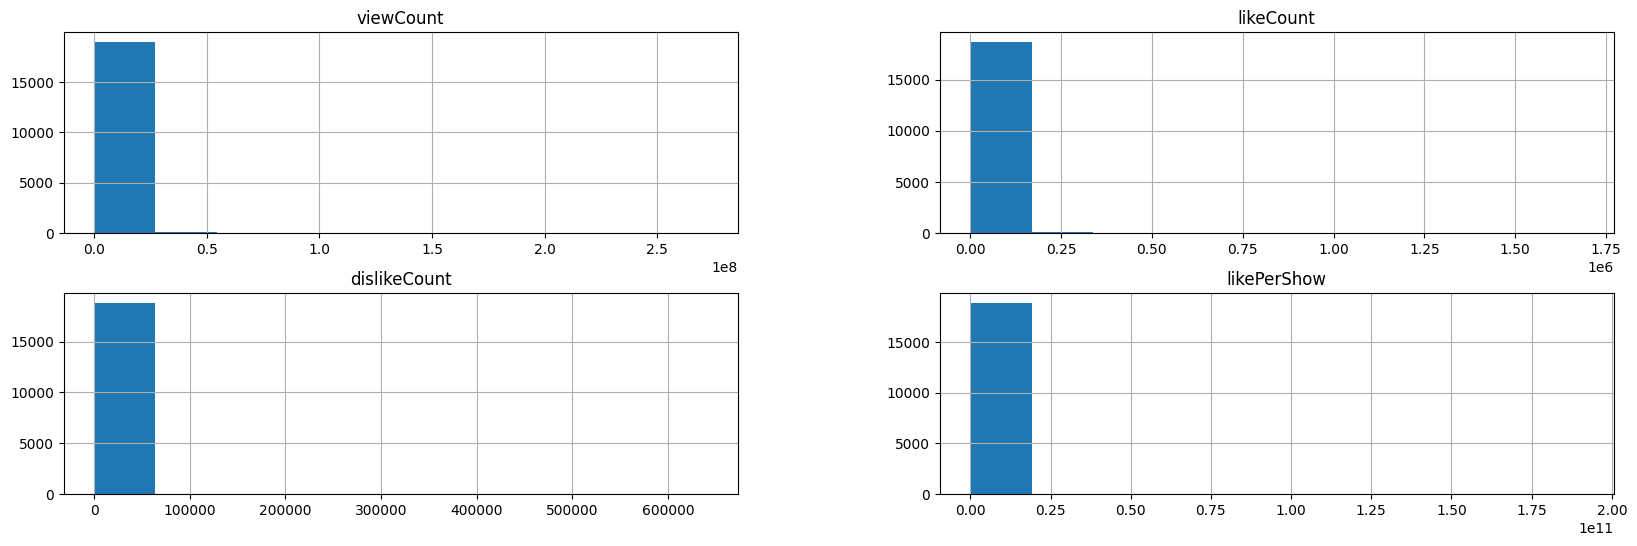

In [52]:
columns = ['viewCount', 'likeCount', 'dislikeCount', 'likePerShow']
df[columns].hist(figsize=(20, 6));

You can also plot many histograms for the logarithms of variables. This way, outliers are smoothed out, and the nature of the data becomes clearer.

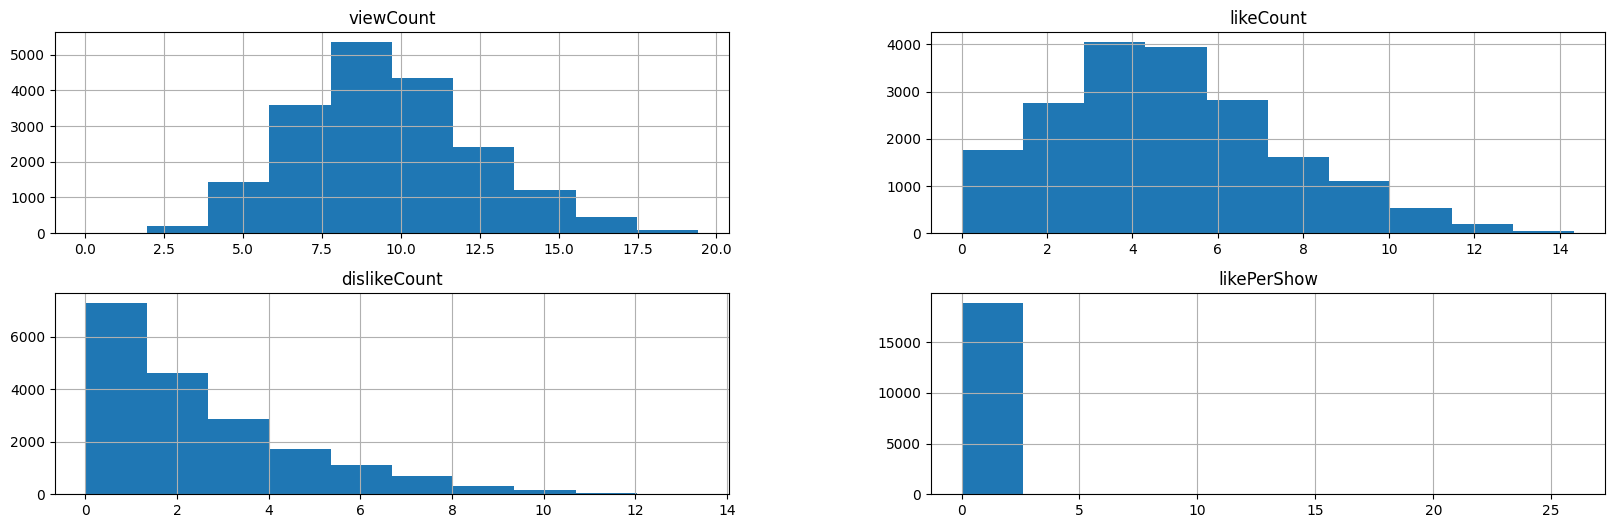

In [53]:
df[columns].apply(lambda x: np.log(x + 1)).hist(figsize=(20, 6));

## 4. Working with Missing Data

Missing data occurs for various reasons. Someone might have forgotten to measure, record, or such data simply doesn't exist. When we start working with machine learning algorithms, we'll need to fill in all these missing values.

To check if a table cell is missing, you can use the `.isnull()` method.

In [54]:
df.likeCount.isnull()  # returns True if the cell is missing, otherwise False

,likeCount
0,False
1,False
2,False
3,False
4,False
...,...
19119,False
19120,False
19121,False
19122,False


In [55]:
df.likeCount.isnull().sum()

np.int64(274)

In [56]:
df.isnull().sum()      # total number of missing values in each column

,0
title,0
commentCount,210
dislikeCount,274
likeCount,274
music_style,0
performer,0
viewCount,1
comments_obscene_cnt,6810
videoAge,0
likePerShow,275


In [57]:
# sorted by the number of missing values in descending order
df.isnull().sum().sort_values(ascending=False)

,0
comments_obscene_cnt,6810
likePerShow,275
dislikeCount,274
likeCount,274
commentCount,210
viewCount,1
title,0
music_style,0
performer,0
videoAge,0


The `.fillna(something)` method allows you to fill missing values with something neutral. For example, let's look at the `city` column. It currently contains missing values. Missing values can be filled in different ways depending on the task. Sometimes they are simply discarded and not analyzed. Let's fill them in with the median.

In [58]:
med = df.dislikeCount.median()
med

5.0

In [59]:
df.dislikeCount.fillna(med, inplace=True)

/tmp/ipykernel_1016/2426421617.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df.dislikeCount.fillna(med, inplace=True)


Missing values can also be visualized using a heatmap. Cells where `True` were present will be colored yellow, and where `False`, purple.

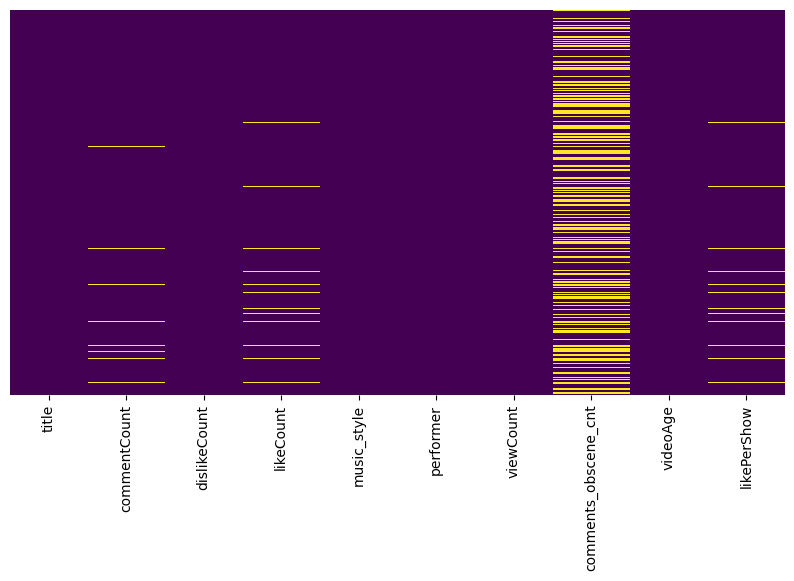

In [60]:
sns_heatmap = sns.heatmap(df.sample(5000).isnull(),
                          yticklabels=False,
                          cbar=False,
                          cmap='viridis')

## 5. Grouping

So, we've learned how to find the average across the entire dataset. But what if we needed to know the average number of likes for each genre?

After thinking about it a bit, we might answer this question using slicing:


In [61]:
# First, let's get the unique genres we have
df['music_style'].unique()

array(['popsa', 'rock', 'classic', 'indi', 'estrada', 'shanson', 'rap'],
      dtype=object)

In [62]:
df[df.music_style == 'popsa'].likeCount.mean()

np.float64(7492.273791654158)

In [63]:
df[df.music_style == 'rap'].likeCount.mean()

np.float64(26802.456253089473)

However, since we have quite a few genres in our dataset, duplicating this code for each genre might seem like a very inefficient solution.

Fortunately, **grouping** was created for tasks like this:

In [64]:
df.groupby('music_style')['likeCount'].mean()

,likeCount
music_style,
classic,28663.333333
estrada,938.686662
indi,2471.842299
popsa,7492.273792
rap,26802.456253
rock,2132.887061
shanson,440.390564


**Let's now explore the possibilities with `groupby`.**


In [65]:
df.groupby(['music_style', 'performer'])[['likeCount', 'dislikeCount'] ].agg(['mean', 'count'])

likeCount       dislikeCount      
                                       mean count         mean count
music_style performer                                               
classic     classical_channel  28663.333333   297  1232.097315   298
estrada     агутин                39.333333     3     4.666667     3
            басков              1582.721311   122   233.270492   122
            буйнов                 2.795455    44     0.727273    44
            ваенга               133.773360   503     9.310139   503
...                                     ...   ...          ...   ...
shanson     жека                 505.681159   138    49.702899   138
            ирина_круг          1520.352381   105   185.847619   105
            михаил_круг          418.111340   485    44.055441   487
            трофимов             252.857759   232    15.478448   232
            шуфутинский          357.132565   347    16.971347   349

[111 rows x 4 columns]

In [66]:
df.groupby(['music_style', 'performer'])[['likeCount', 'dislikeCount'] ].agg({'likeCount': 'min',
                                                                              'dislikeCount': 'max'})

likeCount  dislikeCount
music_style performer                                 
classic     classical_channel        1.0       52892.0
estrada     агутин                   1.0          14.0
            басков                   0.0       11997.0
            буйнов                   0.0          13.0
            ваенга                   1.0         580.0
...                                  ...           ...
shanson     жека                     0.0        3586.0
            ирина_круг               7.0       12906.0
            михаил_круг              0.0        3063.0
            трофимов                 0.0        1037.0
            шуфутинский              0.0        1512.0

[111 rows x 2 columns]

Example of creating a contingency table

In [67]:
df['videoAgeYears'] = df.videoAge // 365 # how many years

In [68]:
df_pivot = df.pivot_table(
    index='videoAgeYears', columns='music_style',
    values='likeCount', aggfunc='median'
)

df_pivot

music_style,classic,estrada,indi,popsa,rap,rock,shanson
videoAgeYears,,,,,,,
0,67.0,12.0,41.5,590.0,3872.5,51.0,5.0
1,74.0,93.5,89.0,711.0,7997.0,101.0,20.5
2,110.5,89.0,26.5,439.0,3126.0,64.5,9.0
3,339.5,56.5,11.0,215.0,4451.0,85.5,18.0
4,1084.5,11.0,14.0,74.0,1153.0,53.0,7.0
5,1198.0,131.5,2220.5,105.0,2842.0,73.5,51.0
6,4263.0,83.5,126.0,104.0,2958.5,119.0,59.5
7,6524.0,72.5,148.0,93.0,1153.0,115.0,251.0
8,10594.0,78.5,54.5,569.0,187.0,115.0,154.0


## 5. More Plots for the Plot God

Creating many plots in matplotlib can be quite cumbersome, often requiring multiple loops. You can see an example of such code at the end of the notebook. To simplify this process, a special plotting package called `seaborn` was created. In `seaborn`, all plots can be made with just one or two commands.


In [69]:
df_log = df[columns].apply(lambda x: np.log(x + 1))
df_log['music_style'] = df['music_style']
df_log.head()

,viewCount,likeCount,dislikeCount,likePerShow,music_style
0,12.275142,7.246368,3.784190,0.006521,popsa
1,14.613657,9.262268,6.538140,0.004730,popsa
2,10.604801,5.598422,2.397895,0.006648,popsa
3,9.384966,5.099866,2.079442,0.013597,popsa
4,11.423919,6.393591,2.995732,0.006505,popsa


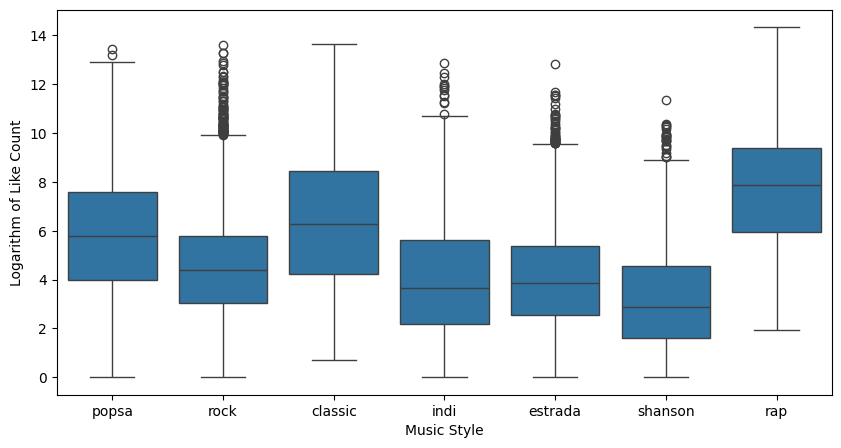

In [70]:
sns.boxplot(x='music_style', y='likeCount', data=df_log)

plt.xlabel('Music Style')
plt.ylabel('Logarithm of Like Count');

You can create a similar plot called a violin plot. It shows the same information as a box plot but looks more visually appealing.

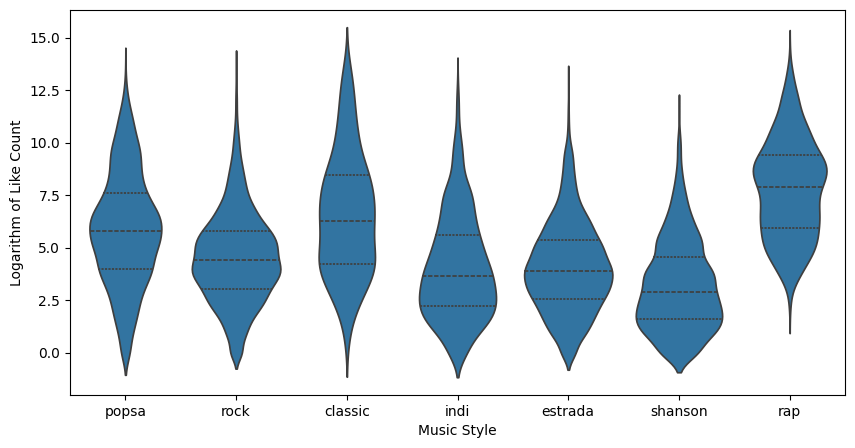

In [71]:
sns.violinplot(x='music_style',
               y='likeCount',
               data=df_log,
               inner="quartile")

plt.xlabel('Music Style')
plt.ylabel('Logarithm of Like Count');


Let's add an additional breakdown by video age:

In [72]:
df_log['isOldVideo'] = df['videoAgeYears'] >= 5

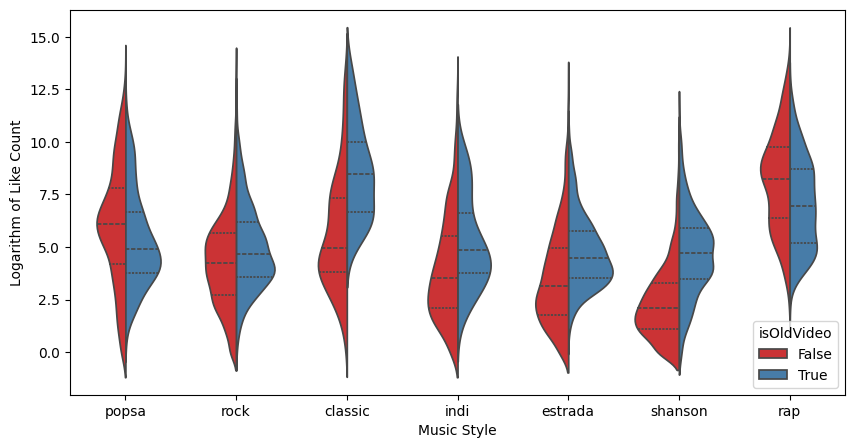

In [73]:
sns.violinplot(x='music_style',
               y='likeCount',
               hue='isOldVideo',
               data=df_log,
               split=True,
               palette='Set1',
               inner='quartile')

plt.xlabel('Music Style')
plt.ylabel('Logarithm of Like Count');

Let's calculate the correlations between continuous variables.

In [74]:
colnames = df.dtypes[df.dtypes == 'float64'].index.values
df[colnames].corr(method='pearson')

,commentCount,dislikeCount,likeCount,viewCount,comments_obscene_cnt,likePerShow
commentCount,1.000000,0.876216,0.743693,0.550143,0.396904,-0.000831
dislikeCount,0.876216,1.000000,0.602914,0.452557,0.381822,-0.000497
likeCount,0.743693,0.602914,1.000000,0.841185,0.394959,-0.000938
viewCount,0.550143,0.452557,0.841185,1.000000,0.260077,-0.001168
comments_obscene_cnt,0.396904,0.381822,0.394959,0.260077,1.000000,-0.001212
likePerShow,-0.000831,-0.000497,-0.000938,-0.001168,-0.001212,1.000000


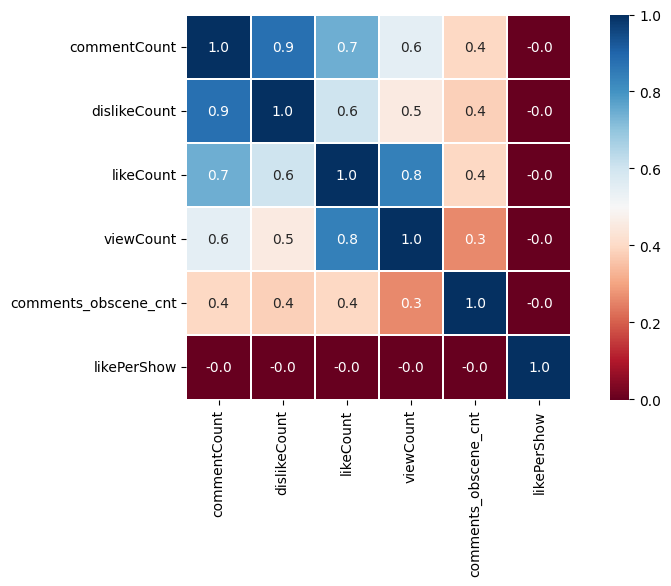

In [75]:
sns.heatmap(df[colnames].corr(method='pearson'),
            square=True, annot=True, fmt=".1f",
            linewidths=0.1, cmap="RdBu");

You can also create pair plots (scatterplot matrices).

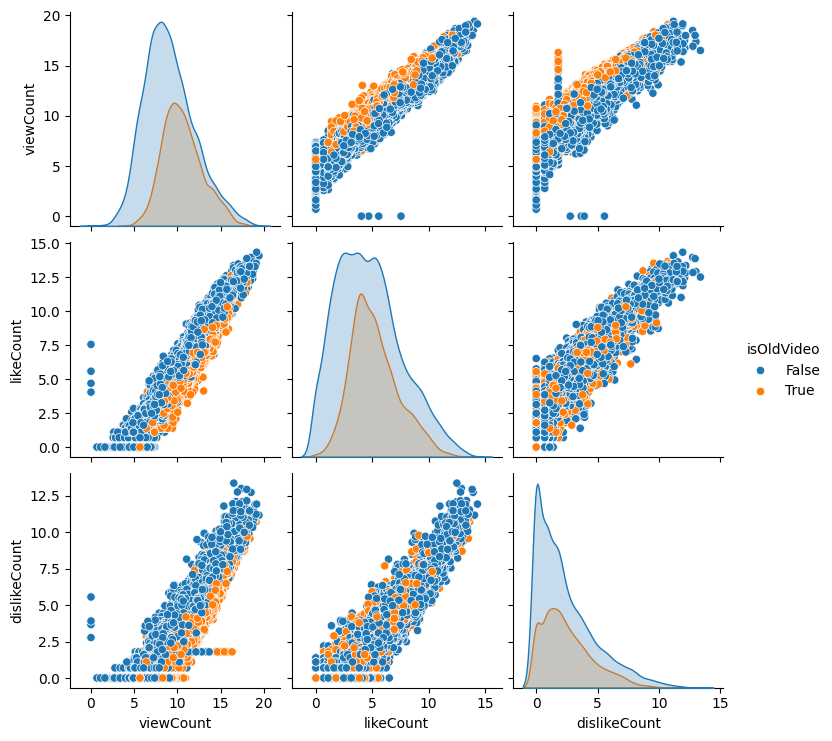

In [76]:
columns = ['viewCount', 'likeCount', 'dislikeCount', 'isOldVideo']
sns.pairplot(df_log[columns], hue='isOldVideo');

Additionally, you can create similar plots for specific variables.

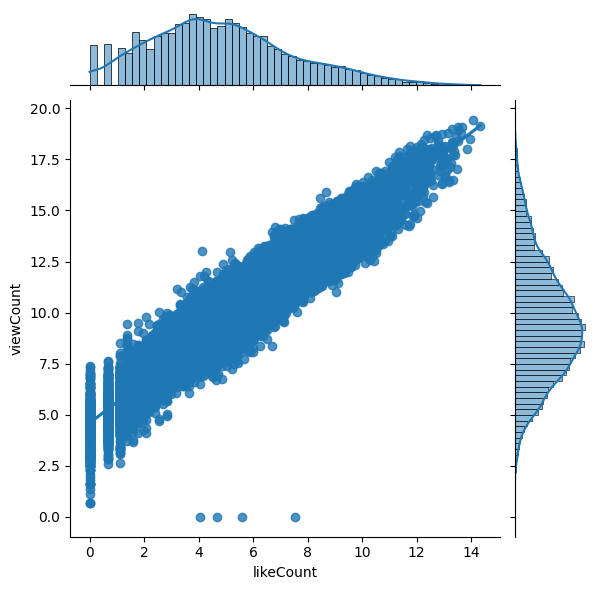

In [77]:
sns.jointplot(x="likeCount", y="viewCount", data=df_log, kind="reg");

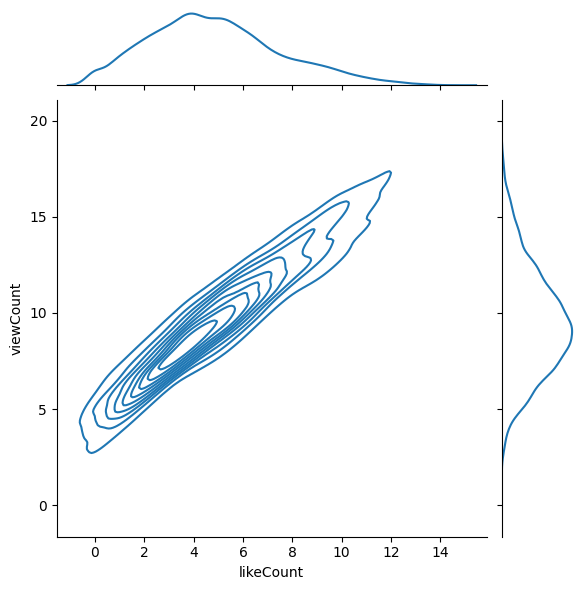

In [78]:
sns.jointplot(x="likeCount", y="viewCount", data=df_log, kind="kde");

In the [seaborn documentation](https://seaborn.pydata.org/examples/index.html), there are many examples of plots that you can "borrow" to make your data notebook more visually appealing.


## 6. More Complex Visualizations

Now let's work with more complex plots that consist of many smaller plots. For example, I want to place a histogram of likes for rap music in the top left. In the bottom right, a histogram of likes for everything else. On the diagonal, we'll have violins and box plots.


In [79]:
df_log['is_rap'] = 1*(df['music_style']  == 'rap')

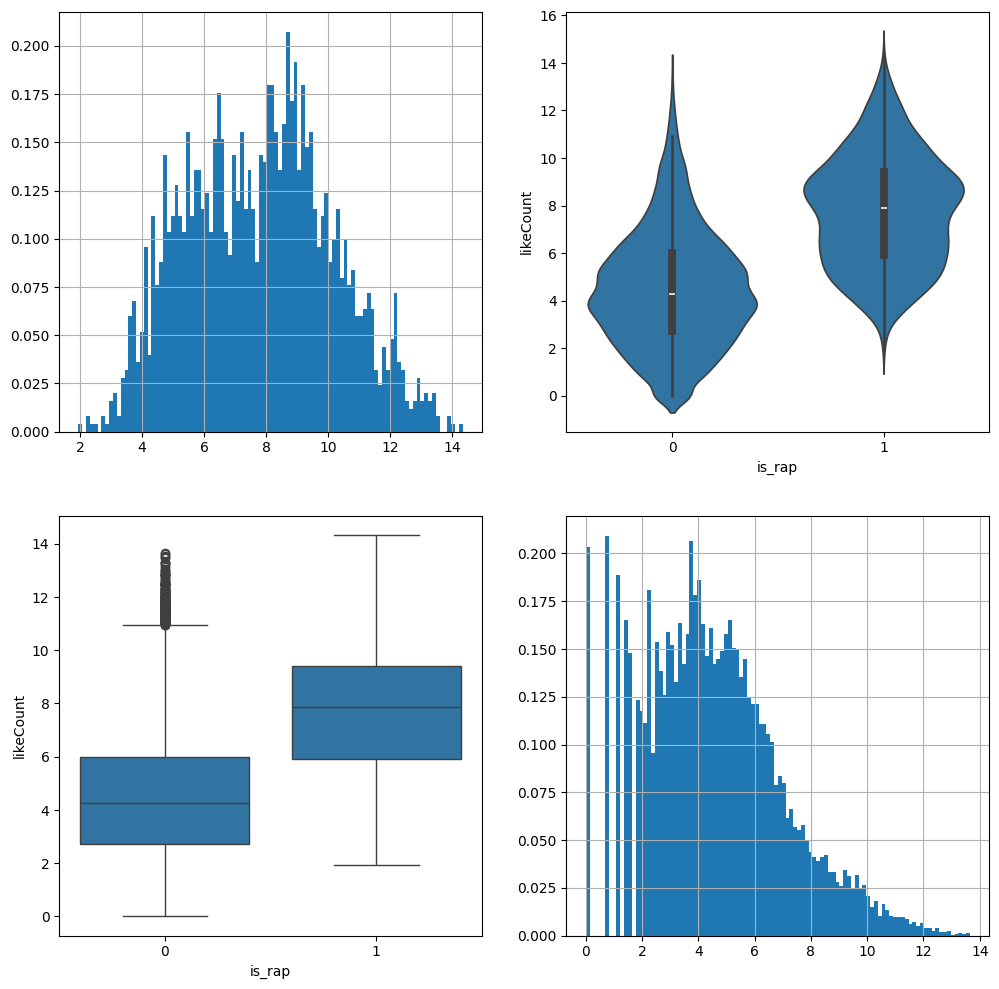

In [80]:
# The first line indicates that I'm going to create a 2x2 grid of plots
_, axes = plt.subplots(2, 2, figsize=(12,12))

# With the additional option ax = axes[i,j], I specify where to draw each plot!
df_log['likeCount'][df_log.is_rap == 1].hist(bins=100, density=True, ax=axes[0, 0])
df_log['likeCount'][df_log.is_rap == 0].hist(bins=100, density=True, ax=axes[1, 1])

sns.boxplot(x='is_rap', y='likeCount', data=df_log, ax=axes[1, 0])
sns.violinplot(x='is_rap', y='likeCount', data=df_log, ax=axes[0, 1]);

Sometimes, you'll need to preprocess the data before creating visualizations. Let's build a bar chart for the genres to understand their distribution.

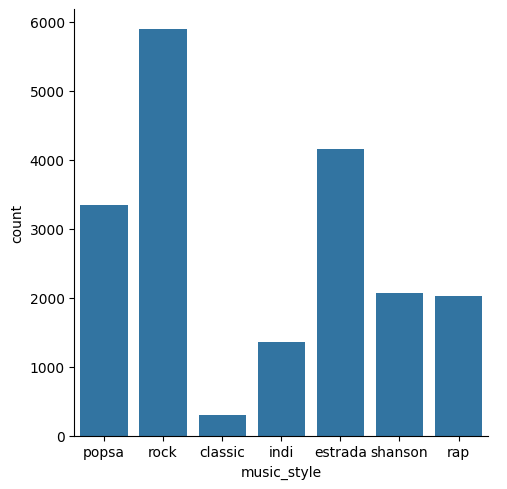

In [81]:
sns.catplot(x='music_style', data=df, kind='count');

You can also stack genres on top of each other in one plot and see how their proportions have changed over the years.

In [82]:
df_pivot = df.pivot_table(index='videoAgeYears', columns='music_style', values='videoAge', aggfunc='count')
df_pivot

music_style,classic,estrada,indi,popsa,rap,rock,shanson
videoAgeYears,,,,,,,
0,26.0,1078.0,462.0,578.0,412.0,1351.0,670.0
1,52.0,387.0,324.0,678.0,284.0,751.0,80.0
2,34.0,244.0,164.0,490.0,305.0,532.0,96.0
3,37.0,305.0,227.0,357.0,213.0,496.0,104.0
4,56.0,486.0,103.0,277.0,181.0,688.0,393.0
5,37.0,302.0,10.0,263.0,105.0,371.0,211.0
6,34.0,188.0,25.0,223.0,104.0,345.0,239.0
7,13.0,226.0,14.0,235.0,221.0,583.0,197.0
8,4.0,622.0,28.0,147.0,104.0,495.0,35.0


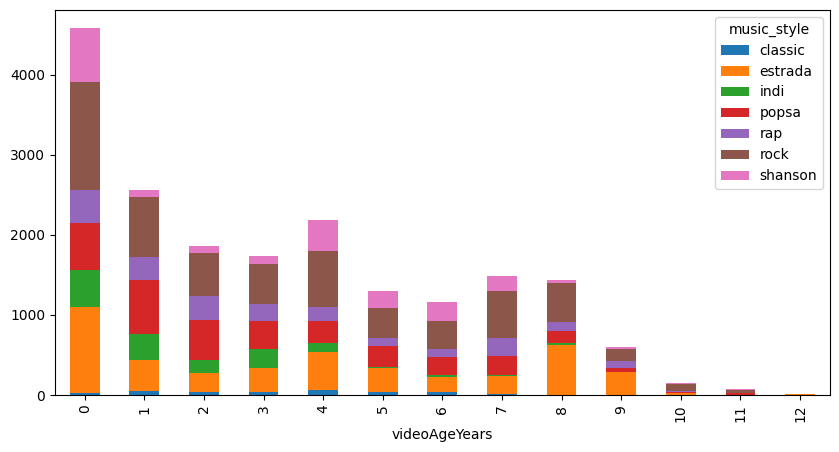

In [83]:
df_pivot.plot(kind='bar', stacked=True);

Sometimes, you need to create plots using a loop. Let's take a look at how this is done so that we don't encounter any issues with it in the future.


In [84]:
# Let's create another categorical variable
top_performers = df.performer.value_counts().index[:20]
df['is_top_performer'] = df.performer.isin(top_performers)

In [85]:
cat_features = ['music_style', 'is_top_performer', 'videoAgeYears']

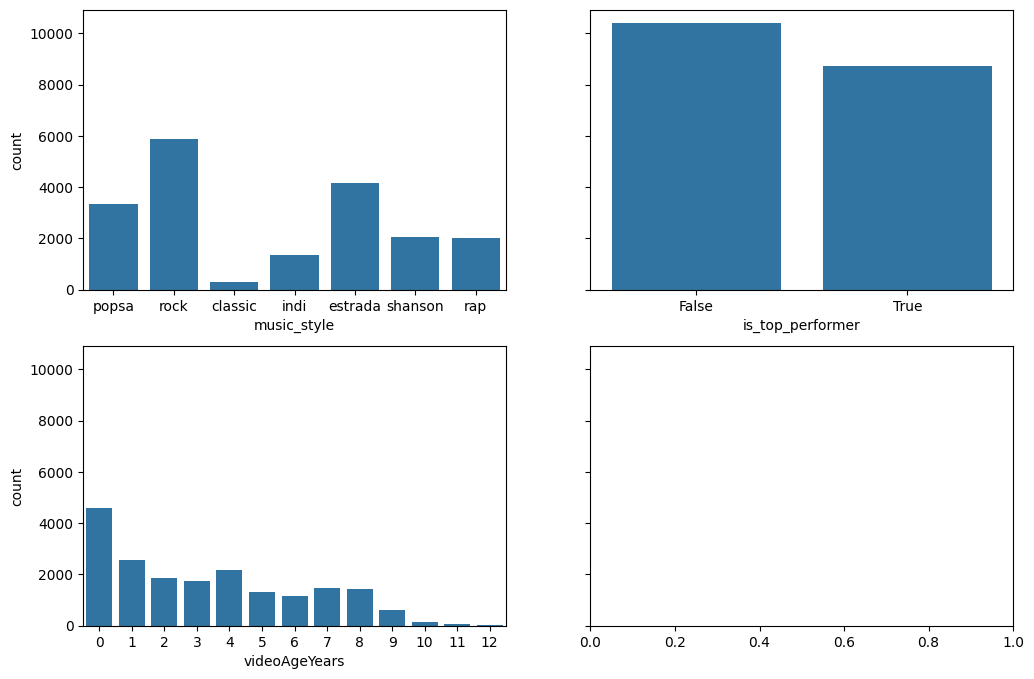

In [86]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=True)

for i in range(len(cat_features)):
    sns.countplot(x=cat_features[i], data=df, ax=axes[i // 2, i % 2])

Another example! We will plot each point with its own color depending on the genre. The size of the point will correspond to how often the genre appears!


In [87]:
sizes = df_log.groupby('music_style').agg('count')['dislikeCount']
sizes

,dislikeCount
music_style,
classic,298
estrada,4151
indi,1359
popsa,3339
rap,2028
rock,5888
shanson,2061


In [88]:
sizes = sizes.to_dict()
sizes

{'classic': 298,
 'estrada': 4151,
 'indi': 1359,
 'popsa': 3339,
 'rap': 2028,
 'rock': 5888,
 'shanson': 2061}

In [89]:
# If desired, you can import a color palette:
# http://seaborn.pydata.org/tutorial/color_palettes.html
colors = 'bgrcmyk'

colors = dict(zip(df.music_style.unique(), list(colors)))
colors

{'popsa': 'b',
 'rock': 'g',
 'classic': 'r',
 'indi': 'c',
 'estrada': 'm',
 'shanson': 'y',
 'rap': 'k'}

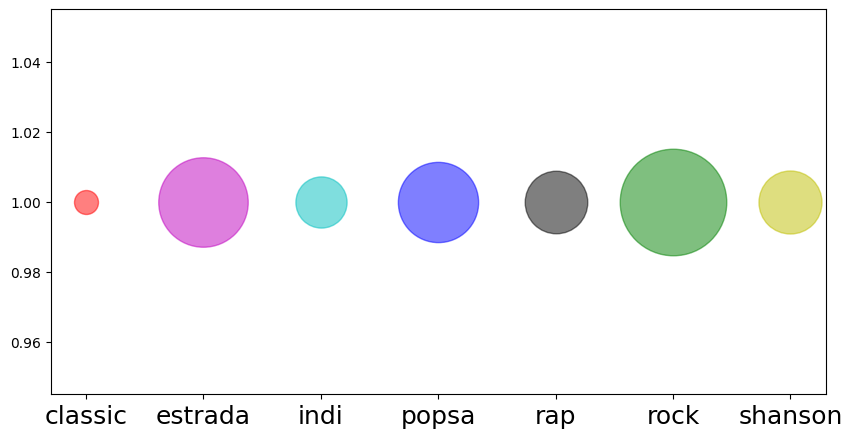

In [90]:
styles = list(sizes.keys())

for i,y in enumerate(styles):
    plt.scatter(i, 1, c=colors[y], alpha=0.5, label=str(y), s=sizes[y])

plt.xticks(ticks=list(range(len(styles))) , labels=styles, size=18);

This is a very unusual visualization, included here just as an example, so you understand that you can get very creative with these.

## 7. Another useful methods

**Reset index**

In [91]:
df.iloc[[10, 20, 30, 40], [0, 1]].reset_index(drop=True)

,title,commentCount
0,"""LAZERBOY""( Michael Yousher videoremix) Сергей...",5.0
1,"""Аве Мария"" Весь зал плакал. Вика 11 лет",3865.0
2,"""Большая семья"" Игоря Николаева - часть 2",3.0
3,"""Всё, что было"". Начало.",23.0


**Unique values**

In [92]:
df['music_style'].value_counts()

,count
music_style,
rock,5888
estrada,4151
popsa,3339
shanson,2061
rap,2028
indi,1359
classic,298


In [93]:
df['music_style'].value_counts(normalize=True)

,proportion
music_style,
rock,0.307885
estrada,0.217057
popsa,0.174597
shanson,0.107770
rap,0.106045
indi,0.071063
classic,0.015583


In [94]:
df['music_style'].unique()

array(['popsa', 'rock', 'classic', 'indi', 'estrada', 'shanson', 'rap'],
      dtype=object)

In [95]:
df['music_style'].nunique()

7

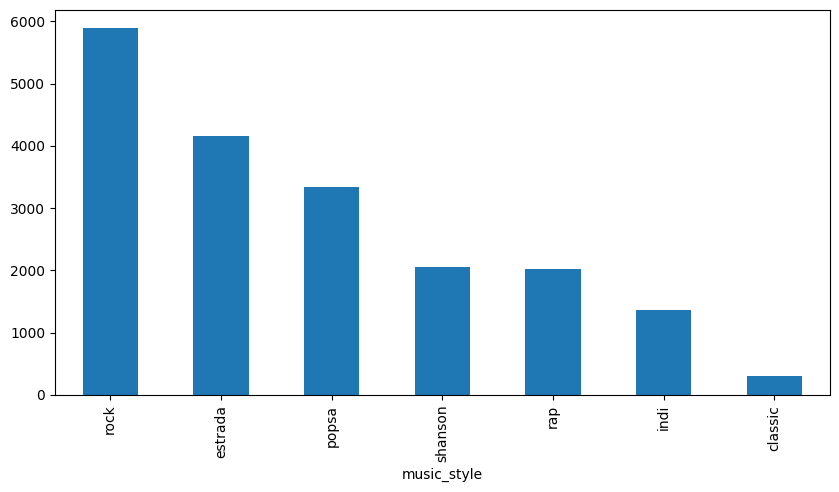

In [96]:
df['music_style'].value_counts().plot(kind='bar');

**Working with Strings**

* `.isin()` — used to filter rows where the category is in a given list
* `.str` — used to apply string methods
* `.str.startswith()` — used to filter rows where the string starts with specific text
* `.str.contains()` — used to filter rows where the content includes specific text
* _and so on; string methods were studied in detail earlier_




In [97]:
interested_styles = ['rock', 'rap']

df['music_style'].isin(interested_styles)

,music_style
0,False
1,False
2,False
3,False
4,False
...,...
19119,False
19120,False
19121,True
19122,True


In [98]:
# conditional slice
df[df['music_style'].isin(interested_styles)].head()

,title,commentCount,dislikeCount,likeCount,music_style,performer,viewCount,comments_obscene_cnt,videoAge,likePerShow,videoAgeYears,is_top_performer
8,"""Hey Tovarish"" Video Shooting",10.0,1.0,34.0,rock,мумий_тролль,3815.0,0.0,2539,0.008912,6,True
15,"""SOS Матросу!"" - тизер фильма",10.0,4.0,68.0,rock,мумий_тролль,7632.0,0.0,1739,0.008910,4,True
36,"""ВОИН ДУМА""",4.0,0.0,49.0,rock,король_и_шут,1950.0,NaN,3819,0.025128,10,False
38,"""Виктор Цой. 50 лет"" Кукрыниксы - Печаль, Конч...",2.0,4.0,65.0,rock,кукрыниксы,9986.0,0.0,2351,0.006509,6,False
40,"""Всё, что было"". Начало.",23.0,5.0,171.0,rock,ария,11168.0,1.0,2351,0.015312,6,False


In [99]:
# extract performers with the first letter 'б'
df[df['performer'].str.startswith('б')].head()

,title,commentCount,dislikeCount,likeCount,music_style,performer,viewCount,comments_obscene_cnt,videoAge,likePerShow,videoAgeYears,is_top_performer
42,"""Глаза - убийцы"". Первые впечатления",3.0,11.0,32.0,popsa,барских,6845.0,1.0,2849,0.004675,7,False
43,"""Глаза - убийцы"". Первые впечатления",4.0,13.0,7.0,popsa,барских,2657.0,1.0,2850,0.002635,7,False
44,"""Глаза - убийцы"". Первые впечатления",11.0,40.0,42.0,popsa,барских,11713.0,1.0,2850,0.003586,7,False
45,"""Глаза - убийцы"". Первые впечатления",1.0,10.0,23.0,popsa,барских,5621.0,1.0,2850,0.004092,7,False
46,"""Глаза - убийцы"". Первые впечатления",5.0,13.0,46.0,popsa,барских,7316.0,1.0,2850,0.006288,7,False


**Changing values**

In [100]:
my_df = pd.DataFrame({'name':['Max', 'Rita', 'Sasha', 'Boris'], 'sex': ['M', 'F', 'F', 'M']})
my_df

,name,sex
0,Max,M
1,Rita,F
2,Sasha,F
3,Boris,M


In [101]:
d = {'M': True, 'F': False}

my_df['is_male'] = my_df.sex.map(d)
my_df

,name,sex,is_male
0,Max,M,True
1,Rita,F,False
2,Sasha,F,False
3,Boris,M,True


In [103]:
np.mean(my_df.is_male)

np.float64(0.5)

## 8. Popularity and Ranking

Very often, analysts receive tasks in an abstract form. For example, if you work at YouTube, you might be asked to find the most popular performers. No one will define what "popularity" means, so you’ll have to figure it out on your own.

### Task 4:

Create a top list of the most popular performers. Come up with your own definition of popularity. Any metric you come up with will have its weak points, so discuss them in detail.



In [104]:
df_popularity = df.copy()

# Fill NaN values in relevant columns with 0, as missing counts can be assumed as zero
df_popularity['likeCount'] = df_popularity['likeCount'].fillna(0)
df_popularity['viewCount'] = df_popularity['viewCount'].fillna(0)
df_popularity['commentCount'] = df_popularity['commentCount'].fillna(0)
df_popularity['dislikeCount'] = df_popularity['dislikeCount'].fillna(0)

# Define a simple popularity score. Higher likes and views contribute positively,
# while dislikes contribute negatively, and comments are also positive.
# Normalizing these features would be more robust for real-world scenarios,
# but for this example, a direct weighted sum is illustrative.
# Coefficients are arbitrary for demonstration purposes.
df_popularity['popularity_score'] = (
    df_popularity['likeCount'] * 0.6 +
    df_popularity['viewCount'] * 0.3 +
    df_popularity['commentCount'] * 0.1 -
    df_popularity['dislikeCount'] * 0.2
)

# Aggregate popularity score by performer
performer_popularity = df_popularity.groupby('performer')['popularity_score'].sum().sort_values(ascending=False)

print("Top 10 Most Popular Performers:")
print(performer_popularity.head(10))

Top 10 Most Popular Performers:
performer
classical_channel    452066426.4
ленинград            408614142.3
тимати               383313589.0
gazgolder            368661437.8
крид                 338297718.9
loboda               176843683.3
мот                  169076703.7
serebro              154996293.3
элджей               132859550.1
михайлов             112464865.4
Name: popularity_score, dtype: float64


### Explanation of Popularity Metric:

For this task, I've defined 'popularity' as a weighted sum of several metrics:

*   **`likeCount` (weighted 0.6):** This is given the highest weight as it directly indicates user approval.
*   **`viewCount` (weighted 0.3):** Views are also a strong indicator of reach and interest, though not necessarily approval.
*   **`commentCount` (weighted 0.1):** Comments show engagement, but are given a lower weight as they can be positive or negative.
*   **`dislikeCount` (weighted -0.2):** Dislikes are a negative indicator of user satisfaction, so they are subtracted.

**Potential Weaknesses of this metric:**

1.  **Arbitrary Weights:** The weights (0.6, 0.3, 0.1, -0.2) are chosen arbitrarily. Different weights could significantly change the ranking. A more data-driven approach (e.g., using regression or machine learning to learn optimal weights from user behavior) would be more robust.
2.  **No Normalization:** The raw counts are used directly. Videos with extremely high views might overshadow videos with very high engagement rates but lower absolute numbers. Normalizing these features (e.g., min-max scaling or z-score standardization) before summing would make the contribution of each feature more balanced.
3.  **Time-Dependency:** Older videos have had more time to accumulate views and likes. This metric doesn't account for `videoAge`, potentially favoring older performers. A better metric might consider a 'popularity per day' or a decaying average.
4.  **No qualitative analysis:** The score doesn't differentiate between the quality of comments or the sentiment of likes/dislikes. A high comment count could be due to controversy, not necessarily popularity.
5.  **Assumption of Missing Values:** Missing `commentCount`, `dislikeCount`, `likeCount`, and `viewCount` values were filled with 0. While this is a common imputation strategy for counts, it assumes a complete lack of activity rather than a lack of data recording.

### Task 5:

Suppose you need to rank videos in a feed based on the statistics collected in the `df` table. How would you rank them? What factors would you consider?

In [105]:
df.columns

Index(['title', 'commentCount', 'dislikeCount', 'likeCount', 'music_style',
       'performer', 'viewCount', 'comments_obscene_cnt', 'videoAge',
       'likePerShow', 'videoAgeYears', 'is_top_performer'],
      dtype='object')

In [106]:
df_feed_ranking = df.copy()

# Fill NaN values in relevant columns with 0 for calculation purposes
df_feed_ranking['likeCount'] = df_feed_ranking['likeCount'].fillna(0)
df_feed_ranking['viewCount'] = df_feed_ranking['viewCount'].fillna(0)
df_feed_ranking['commentCount'] = df_feed_ranking['commentCount'].fillna(0)
df_feed_ranking['dislikeCount'] = df_feed_ranking['dislikeCount'].fillna(0)

# Define an engagement score (similar to previous popularity score)
# Weights are illustrative and can be tuned based on specific goals
df_feed_ranking['engagement_score'] = (
    df_feed_ranking['likeCount'] * 0.5 + # Likes are strong positive signals
    df_feed_ranking['viewCount'] * 0.2 + # Views indicate reach
    df_feed_ranking['commentCount'] * 0.2 + # Comments indicate engagement
    df_feed_ranking['dislikeCount'] * -0.1 # Dislikes are negative signals
)

# Incorporate recency by dividing the engagement score by video age.
# Add 1 to videoAge to avoid division by zero for very new videos (age 0).
# This prioritizes videos with high engagement *per day*.
df_feed_ranking['feed_ranking_score'] = df_feed_ranking['engagement_score'] / (df_feed_ranking['videoAge'] + 1)

# Sort by the new ranking score to get the top videos
top_videos_for_feed = df_feed_ranking.sort_values(by='feed_ranking_score', ascending=False)

print("Top 10 Videos for a Feed based on Feed Ranking Score:")
print(top_videos_for_feed[['title', 'performer', 'music_style', 'likeCount', 'viewCount', 'videoAge', 'feed_ranking_score']].head(10))

Top 10 Videos for a Feed based on Feed Ranking Score:
                                                   title        performer  \
3819   Sergey Lazarev - Scream - Eurovision 2019 ( Ru...          лазарев   
8738   Егор Крид feat. Филипп Киркоров - Цвет настрое...             крид   
18664                                Элджей - California           элджей   
1304   FACE – ЮМОРИСТ (Original Motion Picture Soundt...             face   
18649                      Элджей & Feduk - Розовое вино            feduk   
2635   Miyagi & Эндшпиль feat. Рем Дигга - I Got Love...  miyagi&эндшпиль   
186          #2Маши "МАМА, Я ТАНЦУЮ " [ ПРЕМЬЕРА КЛИПА ]            2маши   
205                                       #2Маши - Босая            2маши   
8713           Егор Крид - Крутой (премьера клипа, 2019)             крид   
1303                               FACE – МОЙ КАЛАШНИКОВ             face   

      music_style  likeCount    viewCount  videoAge  feed_ranking_score  
3819        popsa    996